# Conhecendo a base

O diabetes é uma doença crônica grave na qual os indivíduos perdem a capacidade de regular efetivamente os níveis de glicose no sangue e pode levar a uma redução na qualidade de vida e na expectativa de vida.

O Sistema de Vigilância de Fatores de Risco Comportamentais (BRFSS) é uma pesquisa telefônica relacionada à saúde que é coletada anualmente pelo CDC (Centro de Controle e Prevenção de Doenças dos Estados Unidos). A cada ano, a pesquisa coleta respostas de milhares de americanos sobre comportamentos de risco relacionados à saúde, condições crônicas de saúde e o uso de serviços preventivos. Para este projeto, foi utilizado conjunto de dados disponível no Kaggle para o ano de 2015. 

https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset

# Dicionário de dados

Dicionário de variáveis:

- `Diabetes_binary`: 0 = sem diabetes, 1 = com diabetes
- `HighBP`: 0 = sem pressão alta, 1 = com pressão alta
- `HighChol`: 0 = sem colesterol alto, 1 = com colesterol alto
- `CholCheck`: 0 = não fez exame de colesterol na vida, 1 = fez exame de colesterol alguma vez
- `BMI`: Índice de Massa Corporal (IMC)
- `Smoker`: 0 = não fumante, 1 = fumante
- `Stroke`: 0 = sem histórico de AVC, 1 = com histórico de AVC
- `HeartDiseaseorAttack`: 0 = sem histórico de doença cardíaca ou ataque cardíaco, 1 = com histórico de doença cardíaca ou ataque cardíaco
- `PhysActivity`: 0 = não pratica atividade física, 1 = pratica atividade física
- `Fruits`: 0 = não consome frutas, 1 = consome frutas
- `Veggies`: 0 = não consome vegetais, 1 = consome vegetais
- `HvyAlcoholConsump`: 0 = não consome álcool em altas quantidades, 1 = consome álcool em altas quantidades
- `AnyHealthcare`: 0 = não tem plano de saúde, 1 = tem plano de saúde
- `NoDocbcCost`: 0 = não foi ao médico por questões financeiras, 1 = foi ao médico por questões financeiras (últimos 12 meses)
- `GenHlth`: Saúde geral (1 a 5) - 1 = Excelente, 2 = Muito boa, 3 = Boa, 4 = Aceitável, 5 = Ruim
- `MentHlth`: Nos últimos 30 dias, quantos dias a saúde mental não foi boa (0 a 30)
- `PhysHlth`: Nos últimos 30 dias, quantos dias a saúde física não foi boa (0 a 30)
- `DiffWalk`: 0 = não tem dificuldade para caminhar, 1 = tem dificuldade para caminhar
- `Sex`: 0 = feminino, 1 = masculino
- `Age`: Idade em faixas 1 = 18-24; 2 = 25-29; 3 = 30-34; 4 = 35-39; 5 = 40-44; 6 = 45-49; 7 = 50-54; 8 = 55-59; 9 = 60-64; 10 = 65-69; 11 = 70-74; 12 = 75-79; 13 = 80+
- `Education`: Níveis de ensino 1 = nunca frequentou a escola; 2 = escola primária; 3 = escola secundária incompleta ; 4 = escola secundária; 5 = faculdade incompleta ou curso técnico; 6 = completou faculdade ou diplomas superiores
- `Income`: Renda anual em faixas 1 = < 10.000; 2 = 10.000-14.999; 3 = 15.000-19.999; 4 = 20.000-24.999; 5 = 25.000-34.999; 6 = 35.000-49.999; 7 = 50.000-74.999; 8 = 75.000+

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns
from scipy.stats import kstest, norm

from src.auxiliares import (
    analise_levene,
    analise_ttest_ind,
    analise_mannwhitneyu
)

from src.config import DADOS_TRATADOS

In [33]:
df_diabetes_tratado = pd.read_parquet(DADOS_TRATADOS)

df_diabetes_tratado.head()

,Diabetes,PressaoAlta,ColesterolAlto,ColesterolExame,IMC,Fumante,AVC,ProblemaCardiaco,AtividadeFisica,ComeFrutas,...,PlanoSaude,SemDinheiroConsultas,SaudeGeral,DiasProblemasMentais,DiasProblemasFisicos,DificuldadeAndar,Genero,FaixaIdade,Ensino,FaixaRenda
0,Não,Sim,Não,Sim,26,Não,Não,Não,Sim,Não,...,Sim,Não,Boa,5,30,Não,Masculino,35-39,Faculdade +,$75.000+
1,Não,Sim,Sim,Sim,26,Sim,Sim,Não,Não,Sim,...,Sim,Não,Boa,0,0,Não,Masculino,75-79,Faculdade +,$75.000+
2,Não,Não,Não,Sim,26,Não,Não,Não,Sim,Sim,...,Sim,Não,Excelente,0,10,Não,Masculino,80+,Faculdade +,$75.000+
3,Não,Sim,Sim,Sim,28,Sim,Não,Não,Sim,Sim,...,Sim,Não,Boa,0,3,Não,Masculino,70-74,Faculdade +,$75.000+
4,Não,Não,Não,Sim,29,Sim,Não,Não,Sim,Sim,...,Sim,Não,Muito boa,0,0,Não,Femenino,55-59,Faculdade inc. ou Técnico,$75.000+


### Separando os tipos de variáveis

Variáveis numéricas e categóricas precisam de análises diferentes. Também é importante separar a variável-alvo, **Diabetes**, das demais características.

In [34]:
colunas_numericas = df_diabetes_tratado.select_dtypes(include='number').columns.to_list()

colunas_alvo = 'Diabetes'

colunas_categoricas = df_diabetes_tratado.select_dtypes(include='category').columns.to_list()
colunas_categoricas.remove(colunas_alvo)

colunas_binarias = df_diabetes_tratado.nunique()[df_diabetes_tratado.nunique() == 2].index.to_list()
colunas_binarias.remove(colunas_alvo)

colunas_nao_binarias = list(set(colunas_categoricas) - set(colunas_binarias))


## Variáveis numéricas 

### Comparando os grupos com boxplots

**Por que?**  
O boxplot permite comparar rapidamente a posição central, a dispersão e a presença de valores extremos entre pessoas com e sem diabetes.

**Dúvida a responder:**  
As variáveis numéricas parecem ter distribuições diferentes entre os dois grupos?

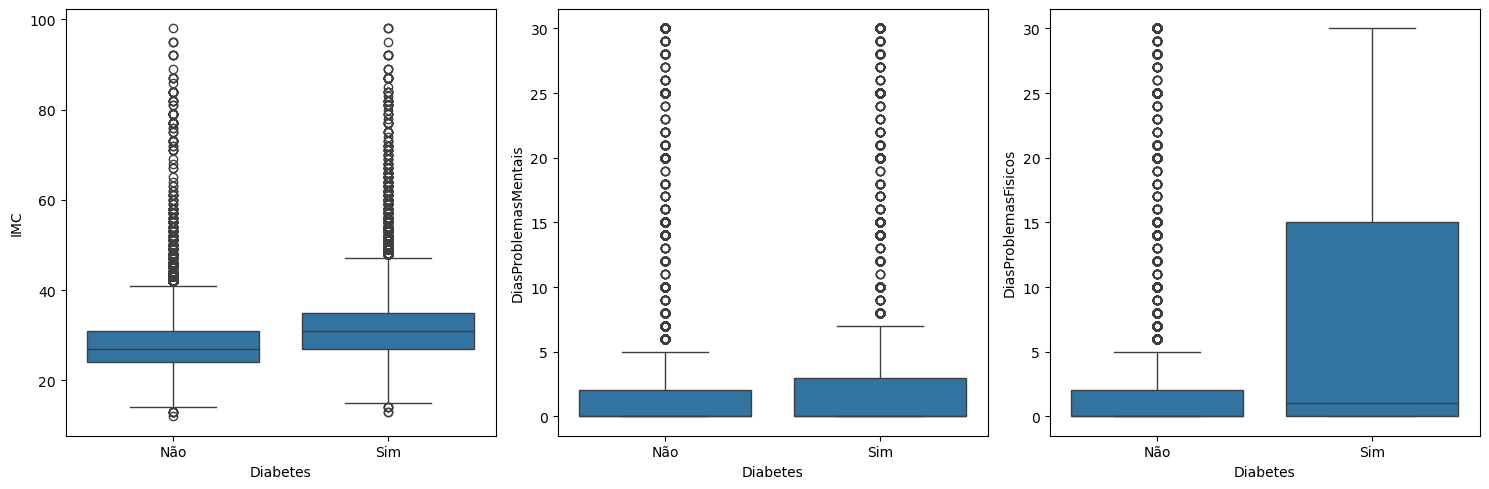

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

for ax, coluna in zip(axs, colunas_numericas):
    sns.boxplot(data=df_diabetes_tratado, x=colunas_alvo, y=coluna, ax=ax)

plt.tight_layout()
plt.show()

> **Resposta:** Visualmente, o grupo com diabetes apresenta **IMC mais alto** e também mais **dias com problemas físicos**. Em dias com problemas mentais a diferença é menor, mas o grupo com diabetes também apresenta maior dispersão.

### Observando o formato das distribuições

**Por que?**  
O histograma mostra onde os valores se concentram e ajuda a identificar assimetria, picos e diferenças de formato entre os grupos.

**Dúvida a responder:**  
As diferenças vistas no boxplot também aparecem quando observamos toda a distribuição dos dados?

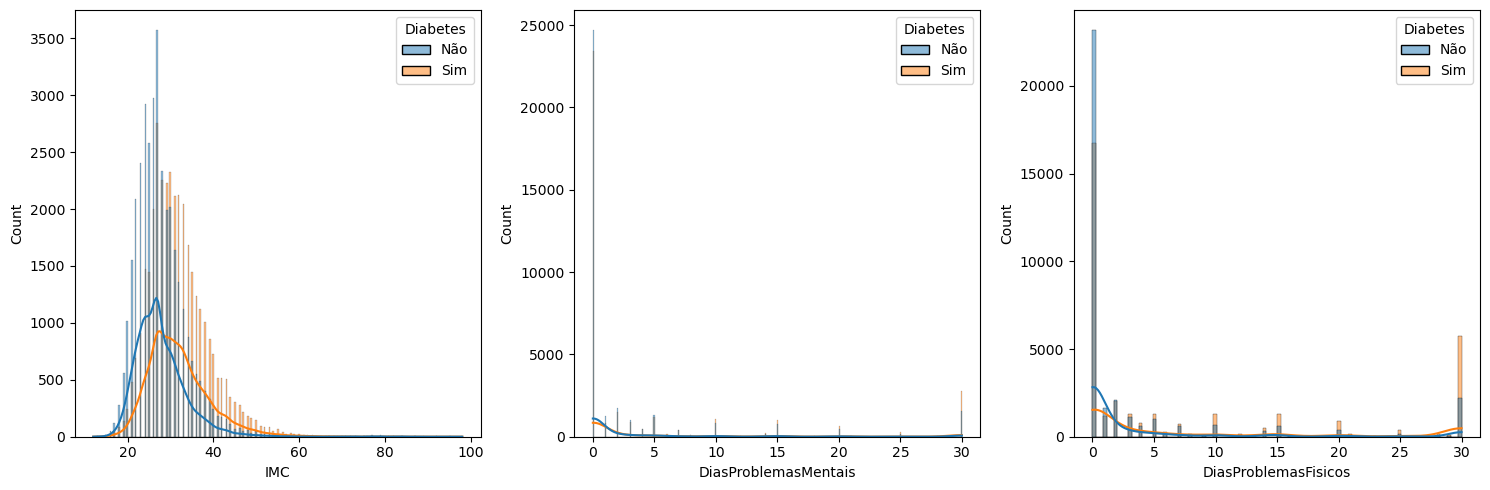

In [36]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

for ax, coluna in zip(axs, colunas_numericas):
    sns.histplot(data=df_diabetes_tratado, x=coluna, hue=colunas_alvo, kde=True, ax=ax)

plt.tight_layout()
plt.show()

> **Resposta:** Sim. A distribuição do **IMC** das pessoas com diabetes está deslocada para valores maiores. Já as variáveis de dias com problemas mentais e físicos têm forte concentração em **zero**, mas o grupo com diabetes aparece com maior presença em valores mais altos, principalmente nos problemas físicos.

### Comparando as estatísticas descritivas

**Por que?**  
Os gráficos mostram o padrão visual, mas as estatísticas descritivas permitem quantificar essas diferenças.

**Dúvida a responder:**  
Quanto as médias e medianas das variáveis numéricas mudam entre pessoas com e sem diabetes?

In [37]:
df_diabetes_tratado.groupby(colunas_alvo, observed=False).describe().T.round(2)

Diabetes                         Não       Sim
IMC                  count  35346.00  35346.00
                     mean      27.77     31.94
                     std        6.19      7.36
                     min       12.00     13.00
                     25%       24.00     27.00
                     50%       27.00     31.00
                     75%       31.00     35.00
                     max       98.00     98.00
DiasProblemasMentais count  35346.00  35346.00
                     mean       3.04      4.46
                     std        7.21      8.95
                     min        0.00      0.00
                     25%        0.00      0.00
                     50%        0.00      0.00
                     75%        2.00      3.00
                     max       30.00     30.00
DiasProblemasFisicos count  35346.00  35346.00
                     mean       3.67      7.95
                     std        8.10     11.30
                     min        0.00      0.00
                     25%        0.00      0.00
                     50%        0.00      1.00
                     75%        2.00     15.00
                     max       30.00     30.00

> **Resposta:** As diferenças ficam mais claras numericamente:
>
> - **IMC médio:** 27,77 sem diabetes e 31,94 com diabetes.
> - **Dias de problemas mentais:** média de 3,04 sem diabetes e 4,46 com diabetes.
> - **Dias de problemas físicos:** média de 3,67 sem diabetes e 7,95 com diabetes.
>
> O maior contraste aparece nos **dias com problemas físicos**, seguido pelo **IMC**.

### Verificando correlação entre as variáveis numéricas

**Por que?**  
Além de comparar os grupos, queremos saber se as próprias variáveis numéricas se movimentam juntas.

**Dúvida a responder:**  
IMC, problemas mentais e problemas físicos apresentam relação linear forte entre si?

In [7]:
df_diabetes_tratado.corr(numeric_only=True)

NameError: name 'df_diabetes_tratado' is not defined

> **Resposta:** Não há correlações fortes. A maior é entre **dias com problemas mentais e dias com problemas físicos (0,38)**, uma relação positiva moderada. As correlações do IMC com problemas mentais (0,10) e físicos (0,16) são fracas.
>
> **Importante:** correlação indica associação, não causa.

- teste t de Student para comparar médias de IMC entre diabéticos e não diabéticos?
- ou teste de Mann-Whitney U para comparar medianas de IMC entre diabéticos e não diabéticos?

### Faz sentido testar a normalidade das variáveis numéricas?

### Avaliando assimetria e curtose

**Por que?**  
Antes de escolher um teste estatístico, é útil verificar se as distribuições se aproximam de uma distribuição normal.

**Dúvida a responder:**  
Os dados numéricos têm formato aproximadamente simétrico e normal?

In [2]:
df_diabetes_tratado.groupby(colunas_alvo, observed=False).skew(numeric_only=True)

NameError: name 'df_diabetes_tratado' is not defined

> **Resposta:** Os valores de assimetria e curtose mostram desvios importantes da normalidade. As distribuições são principalmente **assimétricas à direita**, com maior concentração em valores baixos e uma cauda formada por valores mais altos.
>
> Isso reforça a necessidade de não depender apenas de um teste paramétrico.

### Separando o IMC por grupo

**Por que?**  
A partir daqui, o foco é testar estatisticamente a diferença de **IMC** entre pessoas com e sem diabetes. Para isso, os valores são separados em dois grupos.

**Dúvida a responder:**  
Os valores de IMC dos dois grupos são diferentes de forma estatisticamente significativa?

In [ ]:
df_diabetes_tratado.groupby(colunas_alvo, observed=False)[colunas_numericas].apply(pd.DataFrame.kurtosis)

,IMC,DiasProblemasMentais,DiasProblemasFisicos
Diabetes,,,
Não,12.901012,7.012218,4.910598
Sim,5.717382,2.873176,-0.341922


In [ ]:
dados_imc_sim = df_diabetes_tratado.query("Diabetes == 'Sim'")["IMC"].values

dados_imc_nao = df_diabetes_tratado.query("Diabetes == 'Não'")["IMC"].values

### Testando a normalidade do IMC

**Por que?**  
O teste de Kolmogorov-Smirnov é usado aqui para verificar se o IMC de cada grupo é compatível com uma distribuição normal.

**Dúvida a responder:**  
Podemos considerar o IMC normalmente distribuído nos grupos com e sem diabetes?

In [ ]:
from scipy.stats import kstest, norm

print(kstest(dados_imc_nao, norm.cdf, args=(dados_imc_nao.mean(), dados_imc_nao.std())))
print(kstest(dados_imc_sim, norm.cdf, args=(dados_imc_sim.mean(), dados_imc_sim.std())))

KstestResult(statistic=0.1209153634702329, pvalue=0.0, statistic_location=28, statistic_sign=1)
KstestResult(statistic=0.10452803408478695, pvalue=0.0, statistic_location=33, statistic_sign=1)


> **Resposta:** Não. Nos dois grupos o valor-p é extremamente pequeno, levando à rejeição da hipótese de normalidade.
>
> Como a amostra é muito grande e o IMC está registrado em valores inteiros, o teste também se torna bastante sensível a pequenos desvios. Por isso, o resultado deve ser analisado junto com os histogramas, boxplots, assimetria e curtose.

### Organizando os grupos para os testes

**Por que?**  
Os dois conjuntos de IMC são colocados lado a lado em um DataFrame para facilitar a aplicação dos testes de comparação.

**Dúvida a responder:**  
Os grupos estão organizados de forma adequada para testar variância, média e distribuição?

In [ ]:
dataframe_imc = pd.DataFrame({'Sim': dados_imc_sim, 'Não': dados_imc_nao})

dataframe_imc

,Sim,Não
0,30,26
1,25,26
2,28,26
3,23,28
4,27,29
...,...,...
35341,37,23
35342,29,29
35343,25,24
35344,18,53


> **Resposta:** Sim. Agora temos uma coluna para o grupo **com diabetes** e outra para o grupo **sem diabetes**, permitindo aplicar os mesmos testes diretamente aos dois conjuntos.

### Teste de Levene — comparação das variâncias

**Por que?**  
Antes do teste de médias, verificamos se a variabilidade do IMC é semelhante nos dois grupos.

**Dúvida a responder:**  
A variância do IMC pode ser considerada igual entre pessoas com e sem diabetes?

In [ ]:
analise_levene(dataframe_imc, centro='median')

Teste de Levene
estatistica_levene=888.297
Ao menos uma variância é diferente (valor p: 0.000)


> **Resposta:** Não. O teste de Levene rejeita a igualdade das variâncias (**p < 0,001**). Portanto, na comparação das médias é mais adequado não assumir variâncias iguais.

### Teste t — comparação das médias de IMC

**Por que?**  
Queremos verificar se a diferença observada entre as médias de IMC dos dois grupos é estatisticamente significativa. Como as variâncias são diferentes, o teste é aplicado sem assumir variâncias iguais.

**Dúvida a responder:**  
A média de IMC é igual entre pessoas com e sem diabetes?

In [ ]:
analise_ttest_ind(dataframe_imc, variancias_iguais=False)

Teste t de Student
estatistica_ttest=81.591
Rejeita a hipótese nula (valor p: 0.000)


> **Resposta:** Não. O teste rejeita a hipótese de médias iguais (**p < 0,001**). Junto com a análise descritiva, o resultado indica que o grupo com diabetes apresenta **IMC médio maior**.

### Mann-Whitney — comparação sem assumir normalidade

**Por que?**  
Como o IMC não apresentou normalidade, também usamos um teste não paramétrico para confirmar se a diferença entre os grupos continua presente.

**Dúvida a responder:**  
Mesmo sem assumir distribuição normal, os grupos apresentam comportamento diferente no IMC?

In [ ]:
analise_mannwhitneyu(dataframe_imc)

Teste de Mann-Whitney
estatistica_mw=861173484.000
Rejeita a hipótese nula (valor p: 0.000)


> **Resposta:** Sim. O teste de Mann-Whitney também rejeita a hipótese nula (**p < 0,001**). Assim, tanto o teste paramétrico quanto o não paramétrico apontam diferença entre os grupos.
>
> O Mann-Whitney compara a posição/distribuição dos valores entre os grupos; ele não deve ser interpretado automaticamente apenas como um teste de medianas.

## Os outliers interferem ?

### Removendo os valores extremos para testar a robustez

**Por que?**  
Os boxplots mostraram muitos valores extremos. Agora verificamos se eles são responsáveis pelas diferenças encontradas entre os grupos.

**Dúvida a responder:**  
Se os outliers forem retirados, a conclusão sobre o IMC muda?

### Criando uma versão da base sem outliers

In [47]:
def remove_outliers(dados, bigode=1.5):
    q1 = dados.quantile(0.25)
    q3 = dados.quantile(0.75)
    iqr = q3 - q1

    return dados[(dados >= q1 - bigode * iqr) & (dados <= q3 + bigode * iqr)]

In [48]:
df_diabetes_sem_outliers = df_diabetes_tratado.copy()

for coluna in colunas_numericas:
    df_diabetes_sem_outliers[coluna] = remove_outliers(df_diabetes_sem_outliers[coluna])

df_diabetes_sem_outliers.describe()

,IMC,DiasProblemasMentais,DiasProblemasFisicos
count,68511.000000,58876.000000,60068.000000
mean,29.129673,0.526615,1.880619
std,5.695466,1.271375,3.727202
min,13.000000,0.000000,0.000000
25%,25.000000,0.000000,0.000000
50%,28.000000,0.000000,0.000000
75%,33.000000,0.000000,2.000000
max,45.000000,5.000000,15.000000


> **Resposta:** Os limites ficam bem menores: o IMC passa a ter máximo de **45**, os dias de problemas mentais máximo de **5** e os dias de problemas físicos máximo de **15**. Os valores removidos ficam ausentes nessa cópia, por isso a quantidade válida de observações diminui em cada variável.

### Boxplots depois da remoção dos outliers

**Por que?**  
Repetimos a comparação visual para verificar se a diferença entre os grupos permanecia escondida ou exagerada pelos valores extremos.

**Dúvida a responder:**  
Sem os outliers, o padrão visual entre pessoas com e sem diabetes continua?

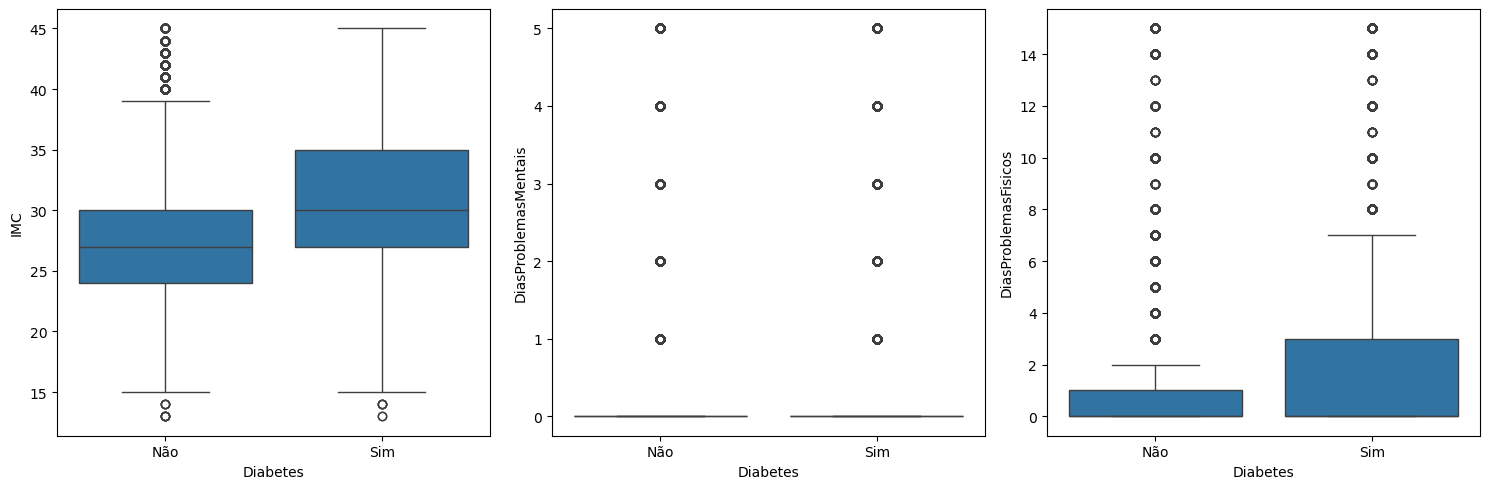

In [49]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

for ax, coluna in zip(axs, colunas_numericas):
    sns.boxplot(data=df_diabetes_sem_outliers, x=colunas_alvo, y=coluna, ax=ax)

plt.tight_layout()
plt.show()

> **Resposta:** Sim. Mesmo sem os valores extremos, o grupo com diabetes continua apresentando **IMC mais alto** e mais **dias com problemas físicos**. Portanto, o padrão principal não desaparece com a remoção dos outliers.

### Distribuições depois da remoção dos outliers

**Por que?**  
O histograma permite conferir se o formato geral das distribuições também permanece depois da retirada dos extremos.

**Dúvida a responder:**  
A diferença entre os grupos continua visível na distribuição dos valores?

In [8]:
fig, axs = plt.subplots(1,3, figsize=(15,5)) 

for ax, coluna in zip(axs, colunas_numericas):
    sns.histplot(data=df_diabetes_sem_outliers, x=coluna, hue=colunas_alvo, kde=True, ax=ax)

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

> **Resposta:** Sim. A distribuição do IMC do grupo com diabetes continua deslocada para valores maiores. As variáveis de problemas mentais e físicos continuam concentradas nos valores mais baixos, mas mantêm diferenças entre os grupos.

### Preparando novamente os grupos de IMC

**Por que?**  
Para repetir os testes estatísticos sem os outliers, separamos novamente o IMC das pessoas com e sem diabetes.

**Dúvida a responder:**  
Os testes anteriores chegam à mesma conclusão quando os valores extremos são desconsiderados?

In [ ]:
dados_imc_sim_sem_outliers = df_diabetes_sem_outliers.query('Diabetes == "Sim"')['IMC'].values

dados_imc_nao_sem_outliers = df_diabetes_sem_outliers.query('Diabetes == "Não"')['IMC'].values

dataframe_imc_sem_outliers = pd.DataFrame({'Sim': dados_imc_sim_sem_outliers, 'Não': dados_imc_nao_sem_outliers})
dataframe_imc_sem_outliers


,Sim,Não
0,30.0,26.0
1,25.0,26.0
2,28.0,26.0
3,23.0,28.0
4,27.0,29.0
...,...,...
35341,37.0,23.0
35342,29.0,29.0
35343,25.0,24.0
35344,18.0,NaN


### Primeira tentativa do teste de normalidade sem outliers

**Por que?**  
Repetimos o teste de normalidade para verificar se a remoção dos extremos aproximou o IMC de uma distribuição normal.

**Dúvida a responder:**  
Depois da retirada dos outliers, o IMC passa a apresentar normalidade?

In [ ]:
print(kstest(dados_imc_nao_sem_outliers, norm.cdf, args=(dados_imc_nao_sem_outliers.mean(), dados_imc_nao_sem_outliers.std()), nan_policy='omit'))
print(kstest(dados_imc_sim_sem_outliers, norm.cdf, args=(dados_imc_sim_sem_outliers.mean(), dados_imc_sim_sem_outliers.std()), nan_policy='omit'))

KstestResult(statistic=nan, pvalue=nan, statistic_location=13.0, statistic_sign=-1)
KstestResult(statistic=nan, pvalue=nan, statistic_location=13.0, statistic_sign=-1)


> **Resposta:** Esta execução retornou **NaN** para a estatística e para o valor-p. Portanto, ela não permite tirar uma conclusão estatística. A análise é repetida na próxima célula usando diretamente as colunas do DataFrame e ignorando os valores ausentes.

### Repetindo corretamente o teste de normalidade

**Por que?**  
Como a tentativa anterior não produziu valores válidos, repetimos o teste com os dados organizados no DataFrame e tratamento dos valores ausentes.

**Dúvida a responder:**  
Sem os outliers, a hipótese de normalidade é aceita?

In [ ]:
print(
    kstest(
        dataframe_imc_sem_outliers['Não'], 
        norm.cdf, 
        args=(dataframe_imc_sem_outliers['Não'].mean(), 
              dataframe_imc_sem_outliers['Não'].std()), 
        nan_policy='omit')
)

print(
    kstest(
        dataframe_imc_sem_outliers['Sim'], 
        norm.cdf, 
        args=(dataframe_imc_sem_outliers['Sim'].mean(), 
              dataframe_imc_sem_outliers['Sim'].std()), 
        nan_policy='omit')
)

KstestResult(statistic=0.10815079726309146, pvalue=0.0, statistic_location=27.0, statistic_sign=1)
KstestResult(statistic=0.07345716240963396, pvalue=2.3370072025339465e-158, statistic_location=30.0, statistic_sign=1)


In [ ]:
analise_levene(dataframe_imc_sem_outliers, centro='median')

Teste de Levene
estatistica_levene=532.986
Ao menos uma variância é diferente (valor p: 0.000)


In [ ]:
analise_ttest_ind(dataframe_imc_sem_outliers, variancias_iguais=False)

Teste t de Student
estatistica_ttest=85.248
Rejeita a hipótese nula (valor p: 0.000)


In [ ]:
analise_mannwhitneyu(dataframe_imc_sem_outliers)

Teste de Mann-Whitney
estatistica_mw=801702843.000
Rejeita a hipótese nula (valor p: 0.000)


## Variáveis categóricas

### Comparando as variáveis binárias

**Por que?**  
Depois das variáveis numéricas, analisamos características com duas respostas possíveis, como pressão alta, colesterol alto, atividade física e histórico de AVC.

**Dúvida a responder:**  
Quais características binárias parecem estar mais associadas à presença de diabetes na amostra?

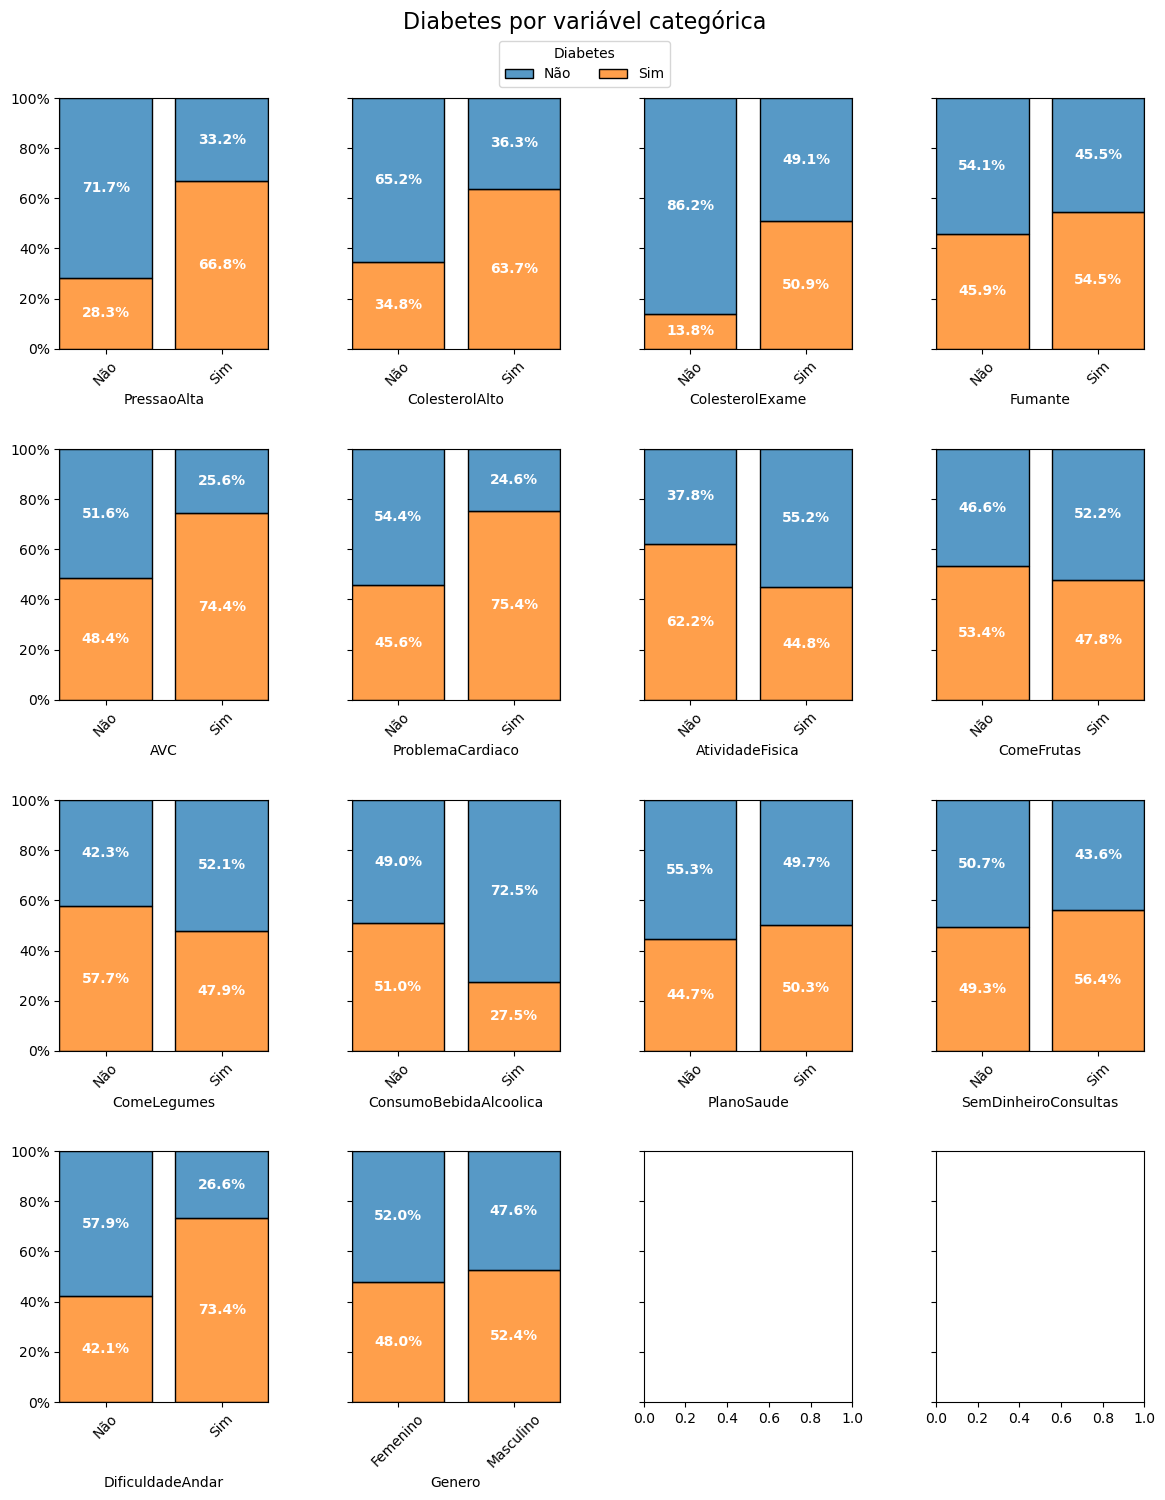

In [ ]:
fig, axs = plt.subplots(nrows=4, ncols=4, figsize=(14, 16), sharey=True)

for i, coluna in enumerate(colunas_binarias):
    h = sns.histplot(x=coluna,
                     hue=colunas_alvo,
                     data=df_diabetes_tratado,
                     multiple='fill',
                     ax=axs.flat[i],
                     stat='percent',
                     shrink=0.8)
    h.tick_params(axis='x', labelrotation=45)

    h.yaxis.set_major_formatter(PercentFormatter(1))
    h.set_ylabel('')

    for bar in h.containers:
        h.bar_label(bar, label_type='center', labels=[f'{b.get_height():.1%}' for b in bar], color='white', weight='bold')

    legend = h.get_legend()
    legend.remove()

labels = [text.get_text() for text in legend.get_texts()]

fig.legend(handles=legend.legend_handles, labels=labels, loc='upper center', ncols=2, title='Diabetes', bbox_to_anchor=(0.5, 0.965))
fig.suptitle('Diabetes por variável categórica', fontsize=16)

fig.align_labels()

plt.subplots_adjust(wspace=0.4, hspace=0.4, top=0.925)

plt.show()

> **Resposta:** Visualmente, algumas diferenças se destacam. **Pressão alta, colesterol alto, problemas cardíacos e dificuldade para andar** aparecem com maior frequência no grupo com diabetes. Já a prática de **atividade física** aparece com menor frequência nesse grupo.
>
> Algumas variáveis, como plano de saúde e gênero, apresentam diferenças bem menores.

### Comparando as variáveis categóricas com várias classes

**Por que?**  
Variáveis como saúde geral, idade, escolaridade e renda possuem várias categorias e podem revelar padrões que não aparecem nas variáveis binárias.

**Dúvida a responder:**  
A distribuição dessas categorias muda entre pessoas com e sem diabetes?

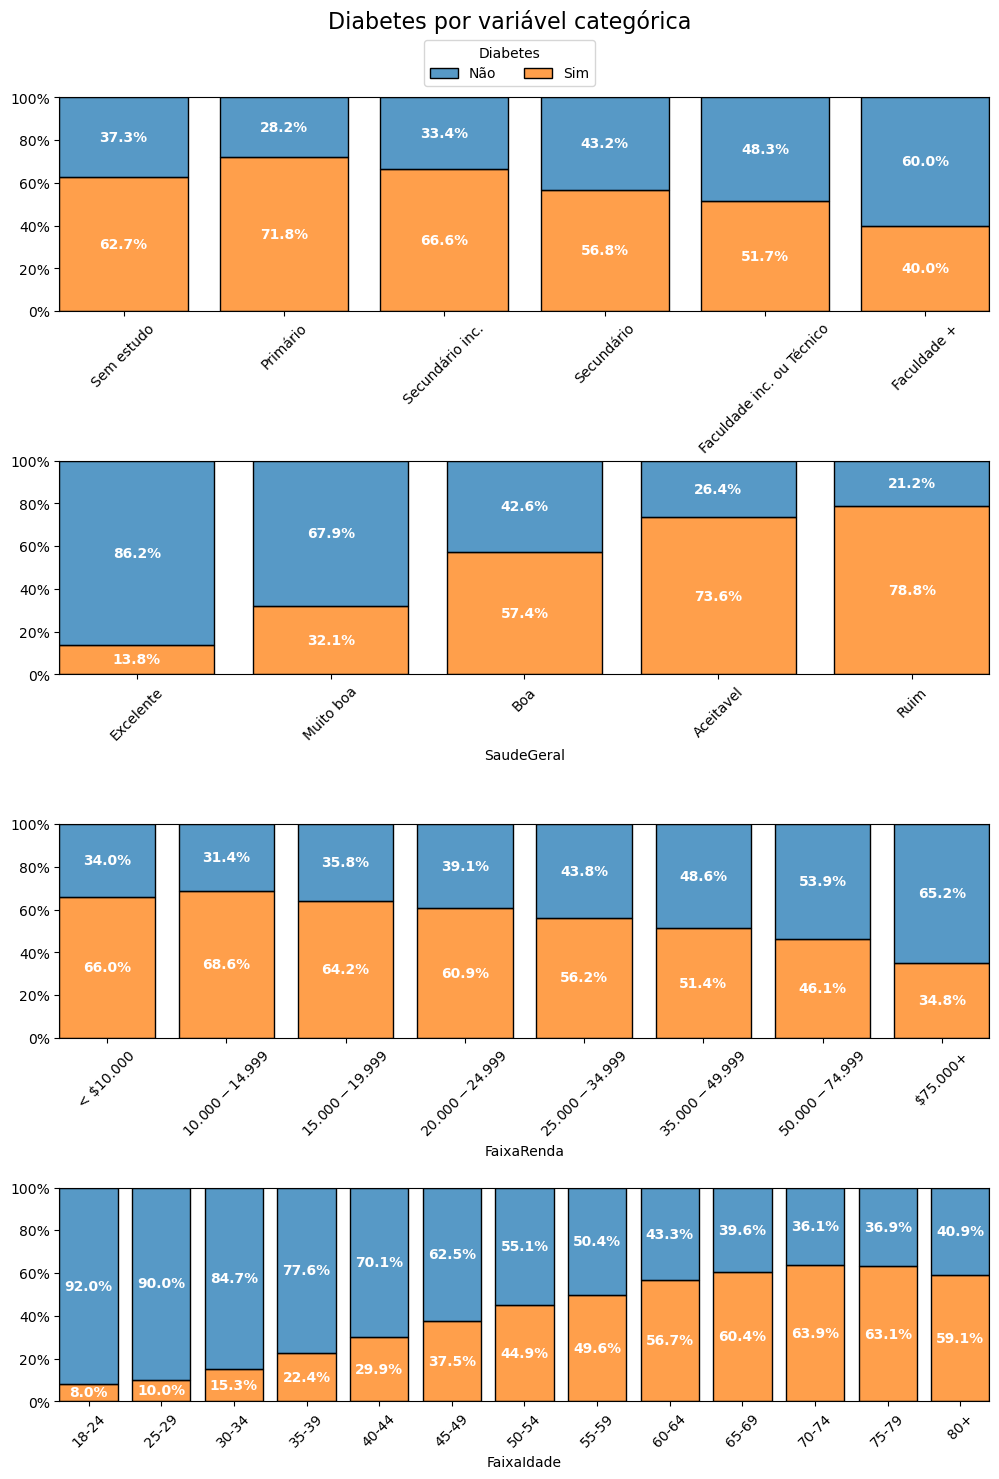

In [ ]:
fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(12, 16))

for i, coluna in enumerate(colunas_nao_binarias):
    h = sns.histplot(x=coluna,
                     hue=colunas_alvo,
                     data=df_diabetes_tratado,
                     multiple='fill',
                     ax=axs.flat[i],
                     stat='percent',
                     shrink=0.8)
    h.tick_params(axis='x', labelrotation=45)

    h.yaxis.set_major_formatter(PercentFormatter(1))
    h.set_ylabel('')

    for bar in h.containers:
        h.bar_label(bar, label_type='center', labels=[f'{b.get_height():.1%}' for b in bar], color='white', weight='bold')

    legend = h.get_legend()
    legend.remove()

labels = [text.get_text() for text in legend.get_texts()]

fig.legend(handles=legend.legend_handles, labels=labels, loc='upper center', ncols=2, title='Diabetes', bbox_to_anchor=(0.5, 0.965))
fig.suptitle('Diabetes por variável categórica', fontsize=16)

fig.align_labels()

plt.subplots_adjust(wspace=0.1, hspace=0.7, top=0.925)

plt.show()

> **Resposta:** Sim. O grupo com diabetes se concentra mais em **idades maiores**, em avaliações piores de **saúde geral** e, de forma geral, em níveis mais baixos de **escolaridade e renda**. Essas diferenças são descritivas e indicam associação, não causalidade.

### Relação entre escolaridade, saúde e renda

**Por que?**  
Além de olhar diretamente para diabetes, é útil entender como fatores sociais se relacionam entre si dentro da base.

**Dúvida a responder:**  
Os níveis de saúde geral e renda mudam conforme o nível de ensino?

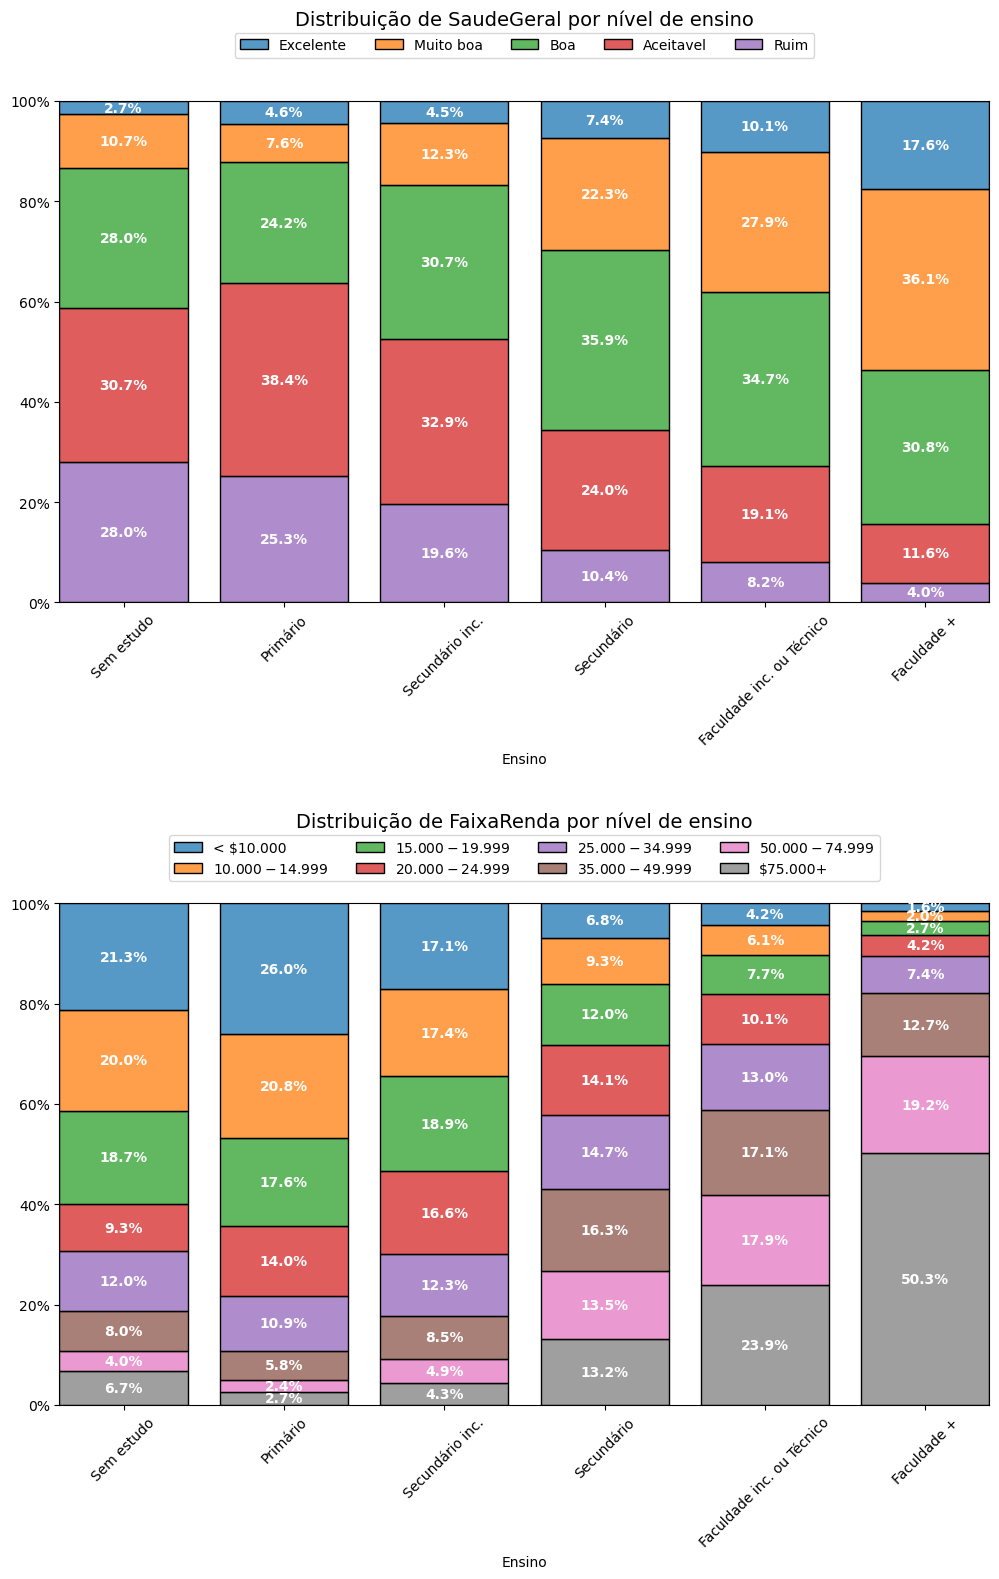

In [ ]:
colunas_analise = ["SaudeGeral", "FaixaRenda"]

fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(12, 16))

for ax, coluna in zip(axs.flatten(), colunas_analise):
    h = sns.histplot(x="Ensino",
                     hue=coluna,
                     data=df_diabetes_tratado,
                     multiple='fill',
                     ax=ax,
                     stat='percent',
                     shrink=0.8)
    h.tick_params(axis='x', labelrotation=45)

    h.yaxis.set_major_formatter(PercentFormatter(1))
    h.set_ylabel('')

    for bar in h.containers:
        h.bar_label(bar, label_type='center', labels=[f'{b.get_height():.1%}' for b in bar], color='white', weight='bold')

    legend = h.get_legend()

    labels = [text.get_text() for text in legend.get_texts()]

    numero_itens = len(df_diabetes_tratado[coluna].cat.categories)

    ax.legend(
        handles=legend.legend_handles,
        labels=labels,
        loc="upper center",
        ncols=numero_itens if numero_itens <= 6 else min(4, numero_itens),
        bbox_to_anchor=(0.5, 1.15),
    )

    ax.set_title(f"Distribuição de {coluna} por nível de ensino", fontsize=14, pad=55)

plt.subplots_adjust(wspace=0.1, hspace=0.6, top=0.925)

plt.show()

> **Resposta:** Sim. Os gráficos sugerem que níveis maiores de ensino aparecem acompanhados por maior participação de categorias de **melhor saúde geral** e **renda mais alta**. Isso mostra que as variáveis socioeconômicas estão relacionadas entre si e devem ser interpretadas em conjunto.

### Criando tabelas de contingência

**Por que?**  
Os gráficos ajudam a enxergar os padrões, mas as tabelas de contingência mostram as quantidades exatas de cada combinação de categorias.

**Dúvida a responder:**  
Quantas pessoas de cada grupo apresentam, por exemplo, pressão alta?

In [ ]:
tabela_contigencia = {}

for coluna in df_diabetes_tratado.select_dtypes('category').columns:
    if coluna != colunas_alvo:
        tabela_contigencia[coluna] = pd.crosstab(df_diabetes_tratado[colunas_alvo], df_diabetes_tratado[coluna])

tabela_contigencia['PressaoAlta']

PressaoAlta,Não,Sim
Diabetes,,
Não,22118,13228
Sim,8742,26604


> **Resposta:** Entre as pessoas sem diabetes, **13.228** apresentam pressão alta e **22.118** não apresentam. Entre as pessoas com diabetes, **26.604** apresentam pressão alta e **8.742** não apresentam. A diferença é bastante clara nessa variável.

### Transformando as tabelas em percentuais

**Por que?**  
Como percentuais são mais fáceis de comparar do que contagens absolutas, normalizamos cada tabela dentro do grupo de diabetes.

**Dúvida a responder:**  
Quais diferenças categóricas ficam mais claras quando comparamos as proporções de cada grupo?

In [ ]:

for coluna in df_diabetes_tratado.select_dtypes('category').columns:
    if coluna != colunas_alvo:
        display(
            pd.crosstab(
                df_diabetes_tratado[colunas_alvo],
                df_diabetes_tratado[coluna],
                margins=True,
                normalize='index'
            ).style.format('{:.2%}'))

PressaoAlta,Não,Sim
Diabetes,,
Não,62.58%,37.42%
Sim,24.73%,75.27%
All,43.65%,56.35%


ColesterolAlto,Não,Sim
Diabetes,,
Não,61.87%,38.13%
Sim,32.99%,67.01%
All,47.43%,52.57%


ColesterolExame,Não,Sim
Diabetes,,
Não,4.27%,95.73%
Sim,0.68%,99.32%
All,2.47%,97.53%


Fumante,Não,Sim
Diabetes,,
Não,56.77%,43.23%
Sim,48.18%,51.82%
All,52.47%,47.53%


AVC,Não,Sim
Diabetes,,
Não,96.81%,3.19%
Sim,90.75%,9.25%
All,93.78%,6.22%


...

DificuldadeAndar,Não,Sim
Diabetes,,
Não,86.58%,13.42%
Sim,62.88%,37.12%
All,74.73%,25.27%


Genero,Femenino,Masculino
Diabetes,,
Não,56.51%,43.49%
Sim,52.09%,47.91%
All,54.30%,45.70%


FaixaIdade,18-24,25-29,30-34,35-39,40-44,45-49,50-54,55-59,60-64,65-69,70-74,75-79,80+
Diabetes,,,,,,,,,,,,,
Não,2.55%,3.55%,4.91%,6.13%,6.99%,8.22%,10.71%,12.28%,12.39%,12.16%,8.21%,5.63%,6.27%
Sim,0.22%,0.40%,0.89%,1.77%,2.97%,4.93%,8.74%,12.06%,16.22%,18.55%,14.54%,9.63%,9.08%
All,1.38%,1.97%,2.90%,3.95%,4.98%,6.58%,9.72%,12.17%,14.30%,15.36%,11.38%,7.63%,7.68%


Ensino,Sem estudo,Primário,Secundário inc.,Secundário,Faculdade inc. ou Técnico,Faculdade +
Diabetes,,,,,,
Não,0.08%,1.31%,3.26%,23.78%,27.38%,44.19%
Sim,0.13%,3.35%,6.50%,31.31%,29.29%,29.42%
All,0.11%,2.33%,4.88%,27.55%,28.33%,36.81%


FaixaRenda,< $10.000,$10.000-$14.999,$15.000-$19.999,$20.000-$24.999,$25.000-$34.999,$35.000-$49.999,$50.000-$74.999,$75.000+
Diabetes,,,,,,,,
Não,3.47%,3.99%,5.63%,7.37%,9.92%,14.13%,17.43%,38.06%
Sim,6.74%,8.73%,10.09%,11.47%,12.74%,14.97%,14.90%,20.36%
All,5.11%,6.36%,7.86%,9.42%,11.33%,14.55%,16.16%,29.21%


Resposta: Os percentuais reforçam os padrões vistos nos gráficos. Alguns exemplos:
- Pressão alta: 75,27% no grupo com diabetes contra 37,42% no grupo sem diabetes.
- Colesterol alto: 67,01% contra 38,13%.
- Problema cardíaco: 22,29% contra 7,27%.
- Dificuldade para andar: 37,12% contra 13,42%.
- Atividade física: 63,05% no grupo com diabetes contra 77,55% no grupo sem diabetes.
- Saúde geral aceitável ou ruim: 40,65% no grupo com diabetes contra 13,42% no grupo sem diabetes.
Esses resultados mostram associações dentro desta amostra. Eles não significam que uma característica, isoladamente, cause diabetes.
Conclusão desta etapa
A análise aponta diferenças consistentes entre os grupos, principalmente em IMC, pressão alta, colesterol alto, problemas físicos, saúde geral e idade. No caso do IMC, a diferença continua estatisticamente significativa mesmo após a retirada dos outliers.
O próximo cuidado é separar significância estatística de importância prática. Como a amostra é grande, valores-p muito pequenos podem aparecer mesmo para diferenças pequenas; por isso, medidas de tamanho de efeito seriam um complemento importante em uma próxima etapa.